# Bandit Problem



총 1,000번만 플레이할 수 있다. 각 머신의 보상 확률을 모른다면, 매번 어떤 머신을 선택해야 총보상을 크게 만들 수 있을까?

- 매 시점 하나의 머신만 선택한다.
- 선택한 머신의 보상만 관찰한다.
- 목표는 제한된 시행 동안 누적 보상을 크게 만드는 것이다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'   # macOS

plt.rcParams['axes.unicode_minus'] = False

rng = np.random.default_rng(42)

## 좋은 슬롯 머신이란?

### 슬롯 머신별 보상 확률분포

| 슬롯 머신 | 0개 동전 | 1개 동전 | 5개 동전 | 10개 동전 |
|---------|---------|---------|---------|----------|
| **A의 확률** | 0.70 | 0.15 | 0.12 | 0.03 |
| **B의 확률** | 0.50 | 0.40 | 0.09 | 0.01 |

In [2]:
reward = np.array([0,1,5,10]) ## 보상
rate_a = np.array([0.7, 0.15, 0.12, 0.03]) ## 확률
rate_b = np.array([0.5, 0.4, 0.09, 0.01]) ## 확률

# 기댓값 계산
expected_value_a = np.sum(reward * rate_a)
expected_value_b = np.sum(reward * rate_b)


### 기댓값(Expected Value) 계산

**좋은 슬롯 머신 = 평균적으로 더 많은 보상을 주는 머신**

#### 기댓값 공식
$$E[X] = \sum_{i} x_i \cdot P(x_i)$$

여기서:
- $x_i$ = 얻을 수 있는 보상 (동전 개수)
- $P(x_i)$ = 그 보상을 얻을 확률

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


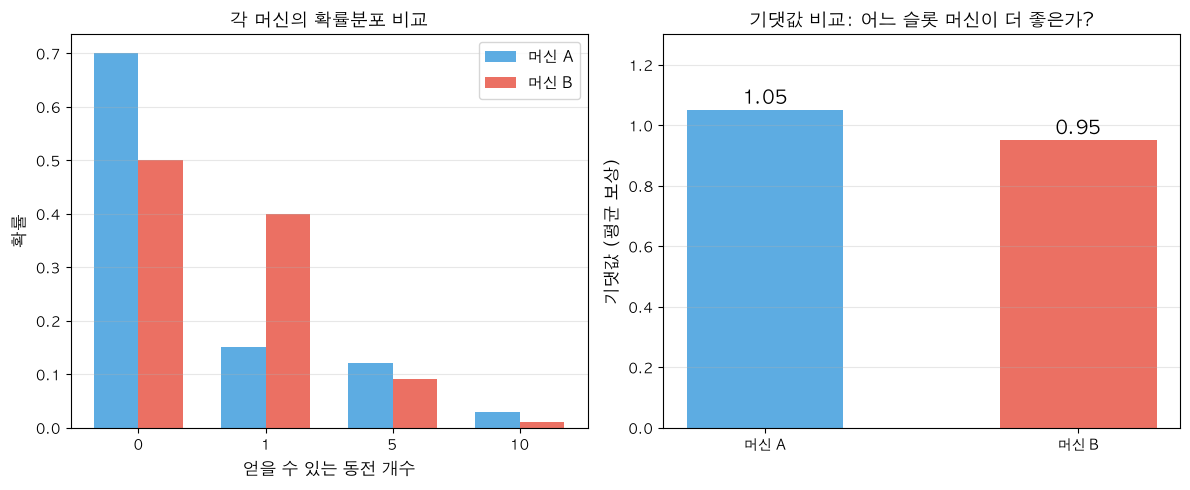

In [3]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. 확률분포 비교
x = np.arange(len(reward))
width = 0.35

axes[0].bar(x - width/2, rate_a, width, label='머신 A', alpha=0.8, color='#3498db')
axes[0].bar(x + width/2, rate_b, width, label='머신 B', alpha=0.8, color='#e74c3c')
axes[0].set_xlabel('얻을 수 있는 동전 개수', fontsize=12, fontweight='bold')
axes[0].set_ylabel('확률', fontsize=12, fontweight='bold')
axes[0].set_title('각 머신의 확률분포 비교', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(reward)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# 2. 기댓값 비교
machines = ['머신 A', '머신 B']
expected_values = [expected_value_a, expected_value_b]
colors = ['#3498db', '#e74c3c']

bars = axes[1].bar(machines, expected_values, color=colors, alpha=0.8, width=0.5)
axes[1].set_ylabel('기댓값 (평균 보상)', fontsize=12, fontweight='bold')
axes[1].set_title('기댓값 비교: 어느 슬롯 머신이 더 좋은가?', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.3)

# 막대 위에 값 표시
for bar, val in zip(bars, expected_values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


시뮬레이션을 만드는 우리는 실제 보상 분포를 알고 있지만, 플레이하는 에이전트는 모른다고 가정한다. 에이전트는 관측한 보상으로 각 머신의 기댓값을 추정한다.

$$
\mathbb{E}[X] = \sum_{i} x_i \cdot P(x_i)
$$

따라서 실제로 슬롯머신을 여러 번 실행하여 얻은 보상의 **표본평균**을 이용한다.

$$
\bar{X} = \frac{1}{n}\sum_{i=1}^{n}X_i
$$

여기서,

- $X_i$ : $i$번째 시행에서 얻은 보상
- $n$ : 시행 횟수
- $\bar{X}$ : 관측된 보상들의 표본평균



In [4]:
# 시도 횟수 지정 
N = 1000

# 슬롯 머신 플레이 
reward_a_n = rng.choice(reward, size=N, replace= True , p=rate_a)
reward_b_n = rng.choice(reward, size=N, replace= True , p=rate_b)
print (reward_a_n[: 10 ])
print (reward_b_n[: 10 ])


# 표본평균 계산 
sample_mean_a_n = np.cumsum(reward_a_n) / np.arange( 1 , N+ 1 )
sample_mean_b_n = np.cumsum(reward_b_n) / np.arange( 1 , N+ 1 )
print (np.round(sample_mean_a_n[: 10 ], 3 ))
print (np.round(sample_mean_b_n[: 10 ], 3 ))

[ 1  0  5  0  0 10  1  1  0  0]
[0 0 0 0 1 0 5 0 1 0]
[1.    0.5   2.    1.5   1.2   2.667 2.429 2.25  2.    1.8  ]
[0.    0.    0.    0.    0.2   0.167 0.857 0.75  0.778 0.7  ]


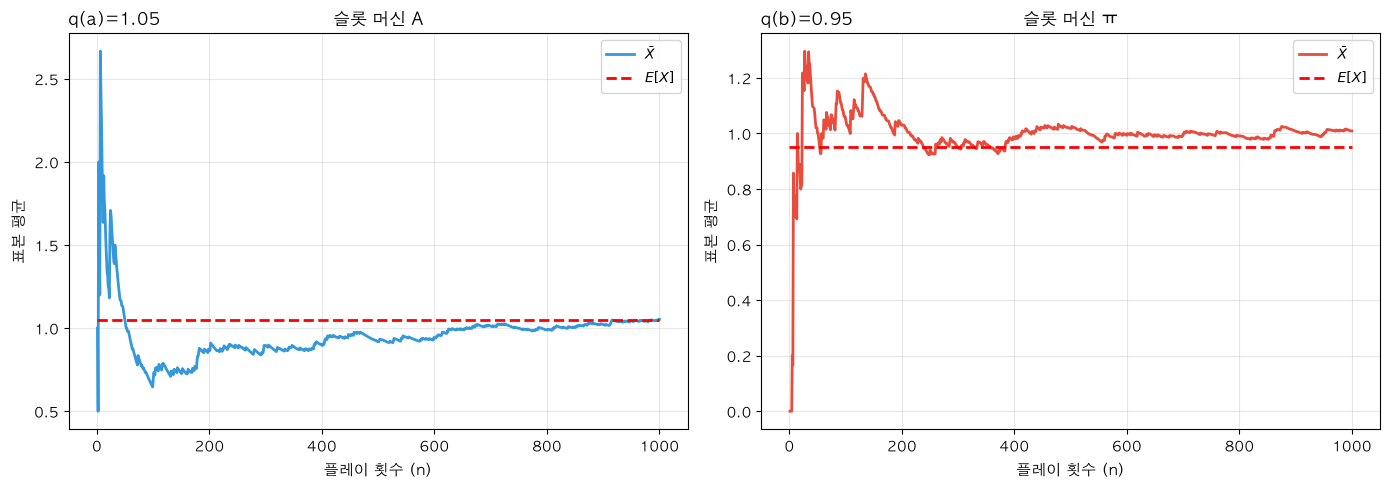

In [5]:
# 그래프: 가로로 나란히 표시
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 머신 A
axes[0].plot(np.arange(1, N+1), sample_mean_a_n, label=r'$\bar{X}$', linewidth=2, color='#3498db')
axes[0].hlines(y=expected_value_a, xmin=0, xmax=N, color='red', linestyle='--', linewidth=2, label=r'$E[X]$')
axes[0].set_xlabel('플레이 횟수 (n)', fontsize=11)
axes[0].set_ylabel('표본 평균', fontsize=11)
axes[0].set_title(f'q(a)={expected_value_a:.2f}', fontsize=12, fontweight='bold', loc='left')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_title("슬롯 머신 A")

# 오른쪽: 머신 B
axes[1].plot(np.arange(1, N+1), sample_mean_b_n, label=r'$\bar{X}$', linewidth=2, color='#e74c3c')
axes[1].hlines(y=expected_value_b, xmin=0, xmax=N, color='red', linestyle='--', linewidth=2, label=r'$E[X]$')
axes[1].set_xlabel('플레이 횟수 (n)', fontsize=11)
axes[1].set_ylabel('표본 평균', fontsize=11)
axes[1].set_title(f'q(b)={expected_value_b:.2f}', fontsize=12, fontweight='bold', loc='left')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].set_title("슬롯 머신 ㅠ")


plt.tight_layout()
plt.show()



시행 횟수 $n$이 충분히 커지면 표본평균은 실제 기댓값에 가까워진다.

$$
\bar{X} \rightarrow E[X] \qquad (n \rightarrow \infty)
$$



이 과정을 여러번 수행하여 결과를 확인한다

In [6]:
# 실험 횟수 지정 
S = 10

# 시도 횟수 지정 
N = 1000

# 슬롯 머신 플레이 
reward_a_sn = rng.choice(reward, size=(S, N), replace= True , p=rate_a)
reward_b_sn = rng.choice(reward, size=(S, N), replace= True , p=rate_b)
print (reward_a_sn[: 3 , : 10 ])
print (reward_b_sn[: 3 , : 10 ])

# 기대치 계산 
sample_mean_a_sn = np.cumsum(reward_a_sn, axis= 1 ) / np.arange( 1 , N+ 1 )
sample_mean_b_sn = np.cumsum(reward_b_sn, axis= 1 ) / np.arange( 1 , N+ 1 )
print (np.round(sample_mean_a_sn[: 3 , : 10 ] , 3 ) ) 
print( np.round(sample_mean_b_sn [: 3 , : 10 ] , 3 ))

[[1 0 5 0 0 5 0 0 0 0]
 [1 0 0 1 0 1 0 0 0 1]
 [1 0 5 0 0 0 0 0 0 0]]
[[ 1  0  0 10  0  0  0  5  1  0]
 [ 0  1  1  0  0  1  1  0  1  0]
 [ 1  1  1  0  0  1  1  5  5  1]]
[[1.    0.5   2.    1.5   1.2   1.833 1.571 1.375 1.222 1.1  ]
 [1.    0.5   0.333 0.5   0.4   0.5   0.429 0.375 0.333 0.4  ]
 [1.    0.5   2.    1.5   1.2   1.    0.857 0.75  0.667 0.6  ]]
[[1.    0.5   0.333 2.75  2.2   1.833 1.571 2.    1.889 1.7  ]
 [0.    0.5   0.667 0.5   0.4   0.5   0.571 0.5   0.556 0.5  ]
 [1.    1.    1.    0.75  0.6   0.667 0.714 1.25  1.667 1.6  ]]


Text(0.5, 1.0, '슬롯 머신 B')

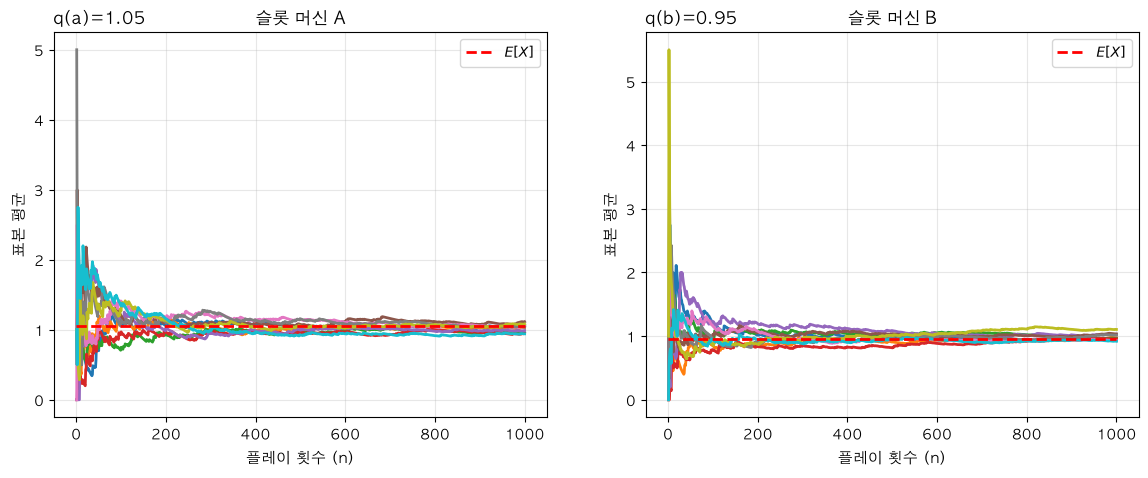

In [7]:
# 기계 a의 ​​실험 결과를 그리기 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for s in  range (S):
    axes[0].plot(np.arange(1, N+1), sample_mean_a_sn[s],  linewidth=2)
axes[0].hlines(y=expected_value_a, xmin=0, xmax=N, color='red', linestyle='--', linewidth=2, label=r'$E[X]$')
axes[0].set_xlabel('플레이 횟수 (n)', fontsize=11)
axes[0].set_ylabel('표본 평균', fontsize=11)
axes[0].set_title(f'q(a)={expected_value_a:.2f}', fontsize=12, fontweight='bold', loc='left')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_title("슬롯 머신 A")

# 기계 b의 ​​실험 결과를 그리기 
for s in  range (S):
    axes[1].plot(np.arange(1, N+1), sample_mean_b_sn[s],  linewidth=2)
axes[1].hlines(y=expected_value_b, xmin=0, xmax=N, color='red', linestyle='--', linewidth=2, label=r'$E[X]$')
axes[1].set_xlabel('플레이 횟수 (n)', fontsize=11)
axes[1].set_ylabel('표본 평균', fontsize=11)
axes[1].set_title(f'q(b)={expected_value_b:.2f}', fontsize=12, fontweight='bold', loc='left')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].set_title("슬롯 머신 B")


따라서 밴디트 문제에서는 **알 수 없는 실제 기댓값을 표본평균을 이용하여 추정한다.**